In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
from scipy.signal import savgol_filter
import os
def ShowDistribution(df):
    # 提取所有速度值
    all_vel = df['v_Vel']
    # 按Vehicle_ID分组计算各指标
    grouped = df.groupby('Vehicle_ID')
    max_speeds = []
    min_speeds = []
    mean_speeds = []
    speed_ranges = []
    for veh_id, group in grouped:
        max_speeds.append(group['v_Vel'].max())
        min_speeds.append(group['v_Vel'].min())
        mean_speeds.append(group['v_Vel'].mean())
        speed_ranges.append(group['v_Vel'].max() - group['v_Vel'].min())

    # 定义五个数据集
    datasets = [
        ('Speed', all_vel),
        ('MaxSpeed', max_speeds),
        ('MinSpeed', min_speeds),
        ('MeanSpeed', mean_speeds),
        ('SpeedRange', speed_ranges)
    ]

    # 创建子图
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    axs = axs.flatten()

    for i, (title, data) in enumerate(datasets):
        min_val = np.min(data)
        max_val = np.max(data)
        bins = np.linspace(min_val, max_val, 300)
        hist, _ = np.histogram(data, bins=bins)
        axs[i].bar(bins[:-1], hist, width=bins[1] - bins[0], align='edge', color='blue', alpha=0.7)
        axs[i].set_title(title, fontsize=14)
        axs[i].set_xlabel('Speed Level', fontsize=12)
        axs[i].set_ylabel('Frequency', fontsize=12)
        axs[i].grid(True, linestyle='--', alpha=0.5)

    # 隐藏多余子图
    if len(datasets) < 6:
        axs[len(datasets)].axis('off')

    plt.tight_layout()

    plt.show()
    
def Trajectoryshow(path):
    df = pd.read_csv(path)  # 替换为实际文件名
    # 随机选择6个车辆ID
    vehicle_ids = df['Vehicle_ID'].unique()
    selected_ids = random.sample(list(vehicle_ids), min(6, len(vehicle_ids)))

    # 创建画布
    plt.figure(figsize=(18, 12))

    for i, veh_id in enumerate(selected_ids):
        veh_data = df[df['Vehicle_ID'] == veh_id]

        # 计算位置差分速度
        dy_velocity = veh_data['Local_Y'].diff()


        # 计算加速度积分速度
        initial_velocity = veh_data['v_Vel'].iloc[0] if not veh_data.empty else 0
        integrated_velocity = initial_velocity + np.cumsum(veh_data['v_Acc'])*0.1

        # 原始速度
        original_velocity = veh_data['v_Vel']

        window_length = 25  # 窗口长度
        poly_order = 3  # 多项式阶数
        #smoothed_velocity = savgol_filter(dy_velocity, window_length, poly_order)
        integrated_velocity = savgol_filter(integrated_velocity, window_length, poly_order)
        original_velocity = savgol_filter(original_velocity, window_length, poly_order)


        # 生成时间步索引（从0开始）
        time_steps = range(len(veh_data))

        # 创建子图 - 位置差分速度
        plt.subplot(6, 3, i*3 + 1)
        plt.plot(time_steps, dy_velocity*3, label='ΔY Velocity')
        plt.title(f'Vehicle {veh_id} - Position Derivative')
        plt.xlabel('Time Step')
        plt.ylabel('Velocity (m/s)')
        plt.grid(True)
        plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围

        # 创建子图 - 原始速度
        plt.subplot(6, 3, i*3 + 2)
        plt.plot(time_steps, original_velocity*0.3, label='Original Velocity')
        plt.title(f'Vehicle {veh_id} - Observed Velocity')
        plt.xlabel('Time Step')
        plt.ylabel('Velocity (m/s)')
        plt.grid(True)
        plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围

        # 创建子图 - 积分速度
        plt.subplot(6, 3, i*3 + 3)
        plt.plot(time_steps, integrated_velocity*0.3, label='Integrated Velocity')
        plt.title(f'Vehicle {veh_id} - Acceleration Integral')
        plt.xlabel('Time Step')
        plt.ylabel('Velocity (m/s)')
        plt.grid(True)
        plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围

    plt.tight_layout()
    plt.show()
def Trajectoryshow_v(path):
    dir_name, file_name = os.path.split(path)
    new_file_name = 'train_data.csv'
    new_path = os.path.join(dir_name, new_file_name)
    real_df = pd.read_csv(new_path)  
    # 从原始数据中提取所有轨迹的初速度
    grouped = real_df.groupby('Vehicle_ID')
    real_initial_vels = [group['v_Vel'].iloc[0] for _, group in grouped]
    
    # 读取生成数据
    df = pd.read_csv(path)
    
    # 随机选择车辆ID
    vehicle_ids = df['Vehicle_ID'].unique()
    selected_ids = random.sample(list(vehicle_ids), min(18, len(vehicle_ids)))
    
    # 创建画布
    plt.figure(figsize=(18, 12))
    
    for i, veh_id in enumerate(selected_ids):
        veh_data = df[df['Vehicle_ID'] == veh_id].copy()  # 复制数据以避免修改原数据
        
#         # 从原始初速度中随机采样一个修正值
#         if real_initial_vels:
#             sampled_initial_vel = random.choice(real_initial_vels)
#             # 计算原始初速度与采样初速度的差值
#             velocity_offset = sampled_initial_vel - veh_data['v_Vel'].iloc[0]
#             # 应用偏移到整个速度序列
#             veh_data['v_Vel'] = veh_data['v_Vel'] + velocity_offset
        
        #veh_data['v_Vel'] = veh_data['v_Vel'].apply(lambda x: max(x, 0))  # 关键修改行
        original_velocity = veh_data['v_Vel']
        time_steps = range(len(veh_data))
        window_length = 22  # 窗口长度
        poly_order = 3  # 多项式阶数
        smoothed_velocity = savgol_filter(original_velocity, window_length, poly_order)

        # 创建子图 - 位置差分速度
        plt.subplot(6, 3, i + 1)  # 调整子图布局索引
       #plt.plot(time_steps, original_velocity*0.3, label='Adjusted Velocity')
        plt.plot(time_steps, smoothed_velocity*0.3)
        plt.title(f'Vehicle {veh_id} ')
        plt.xlabel('Time Step')
        plt.ylabel('Velocity (m/s)')
        plt.grid(True)
        plt.xlim(0, len(veh_data)-1)  # 固定x轴范围
       # plt.legend()

    plt.tight_layout()
    plt.show()



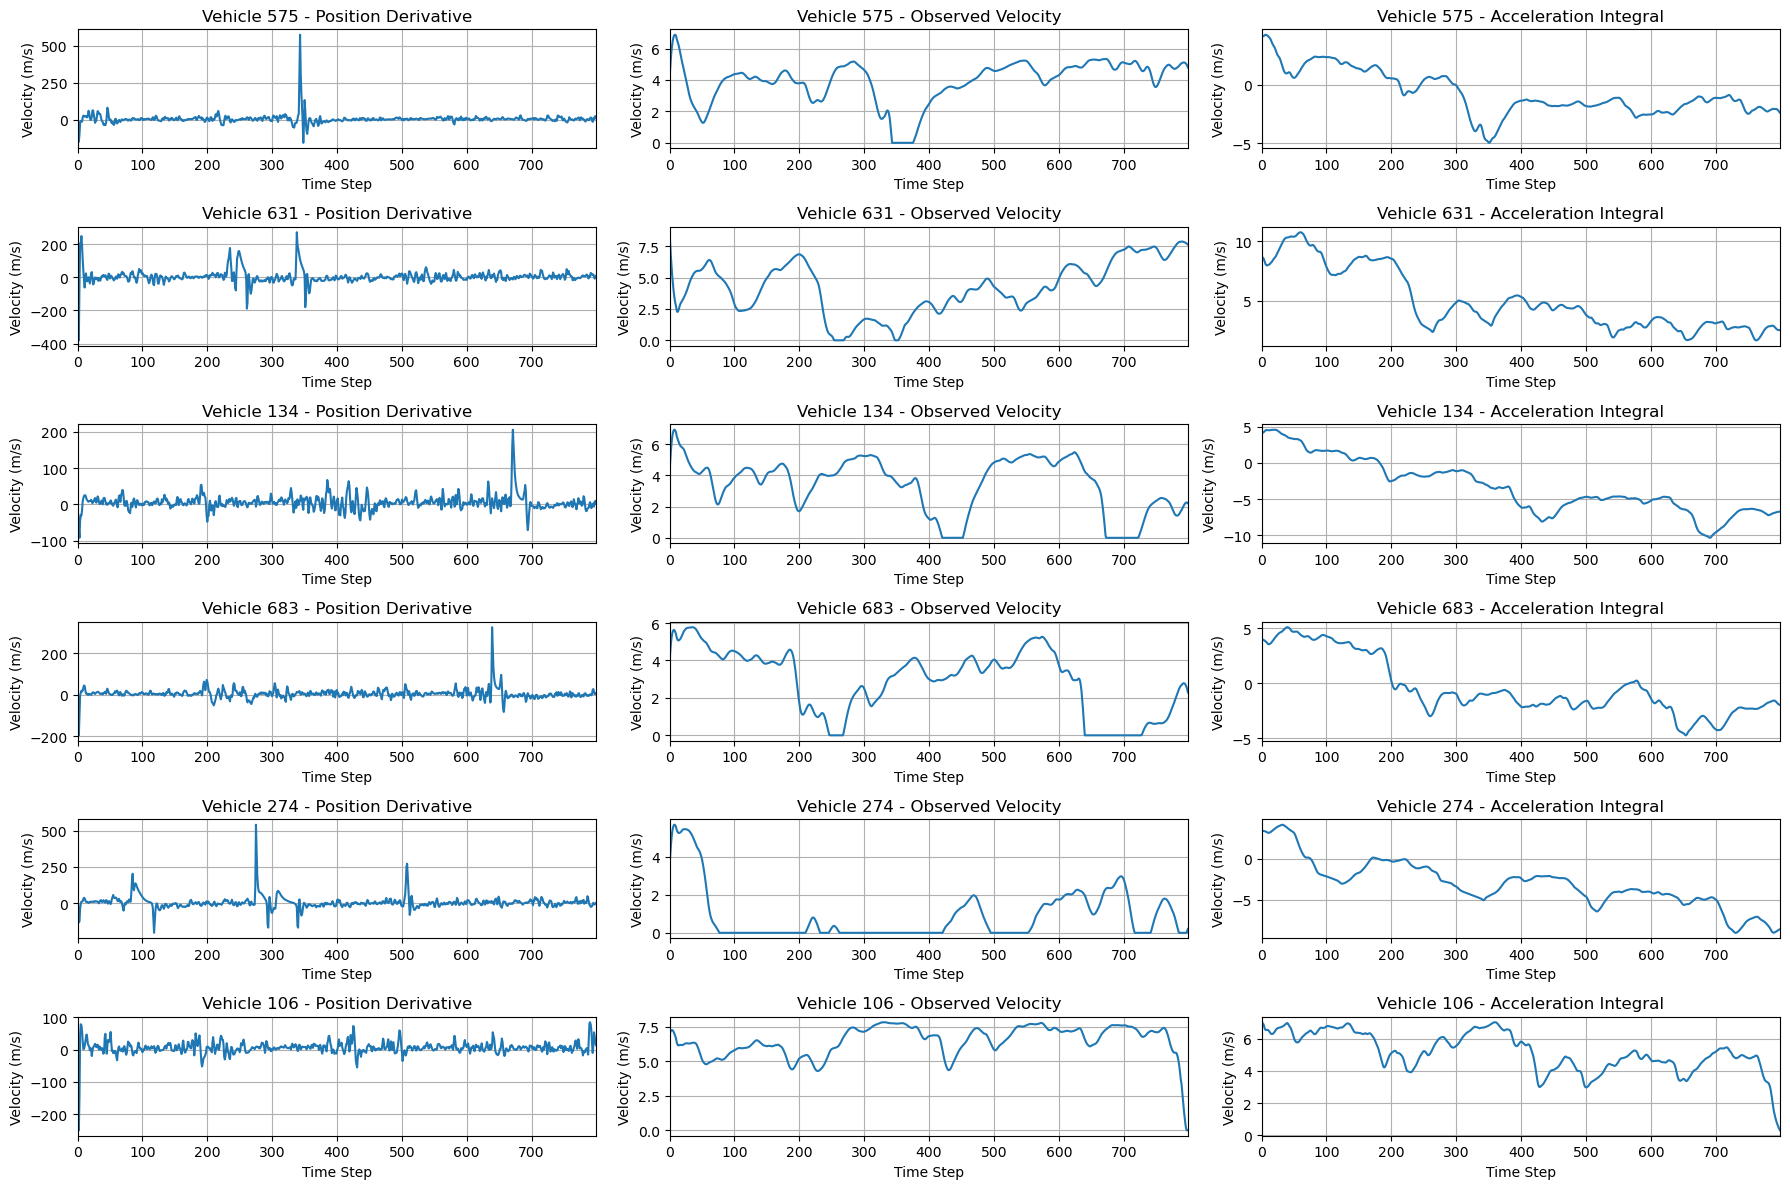

In [32]:
# 读取数据
#df = pd.read_csv('D:/pythonProject/pythonProject/timegan-pytorch/data/smoothed_data.csv')  # 替换为实际文件名
df = pd.read_csv('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/fake_data_model_epoch_1500.csv')  # 替换为实际文件名
# 随机选择6个车辆ID
vehicle_ids = df['Vehicle_ID'].unique()
selected_ids = random.sample(list(vehicle_ids), min(6, len(vehicle_ids)))

# 创建画布
plt.figure(figsize=(18, 12))

for i, veh_id in enumerate(selected_ids):
    veh_data = df[df['Vehicle_ID'] == veh_id]
    
    
    # 计算位置差分速度
    dy_velocity = veh_data['Local_Y'].diff()
    
    
    # 计算加速度积分速度
    initial_velocity = veh_data['v_Vel'].iloc[0] if not veh_data.empty else 0
    integrated_velocity = initial_velocity + np.cumsum(veh_data['v_Acc'])*0.1
    
    # 原始速度
    original_velocity = veh_data['v_Vel']
    
    # 生成时间步索引（从0开始）
    time_steps = range(len(veh_data))
    
    # 创建子图 - 位置差分速度
    plt.subplot(6, 3, i*3 + 1)
    plt.plot(time_steps, dy_velocity*3, label='ΔY Velocity')
    plt.title(f'Vehicle {veh_id} - Position Derivative')
    plt.xlabel('Time Step')
    plt.ylabel('Velocity (m/s)')
    plt.grid(True)
    plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围
    
    # 创建子图 - 原始速度
    plt.subplot(6, 3, i*3 + 2)
    plt.plot(time_steps, original_velocity*0.3, label='Original Velocity')
    plt.title(f'Vehicle {veh_id} - Observed Velocity')
    plt.xlabel('Time Step')
    plt.ylabel('Velocity (m/s)')
    plt.grid(True)
    plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围
    
    # 创建子图 - 积分速度
    plt.subplot(6, 3, i*3 + 3)
    plt.plot(time_steps, integrated_velocity*0.3, label='Integrated Velocity')
    plt.title(f'Vehicle {veh_id} - Acceleration Integral')
    plt.xlabel('Time Step')
    plt.ylabel('Velocity (m/s)')
    plt.grid(True)
    plt.xlim(0, len(veh_data)-1)  # 可选：固定x轴范围

plt.tight_layout()
plt.show()

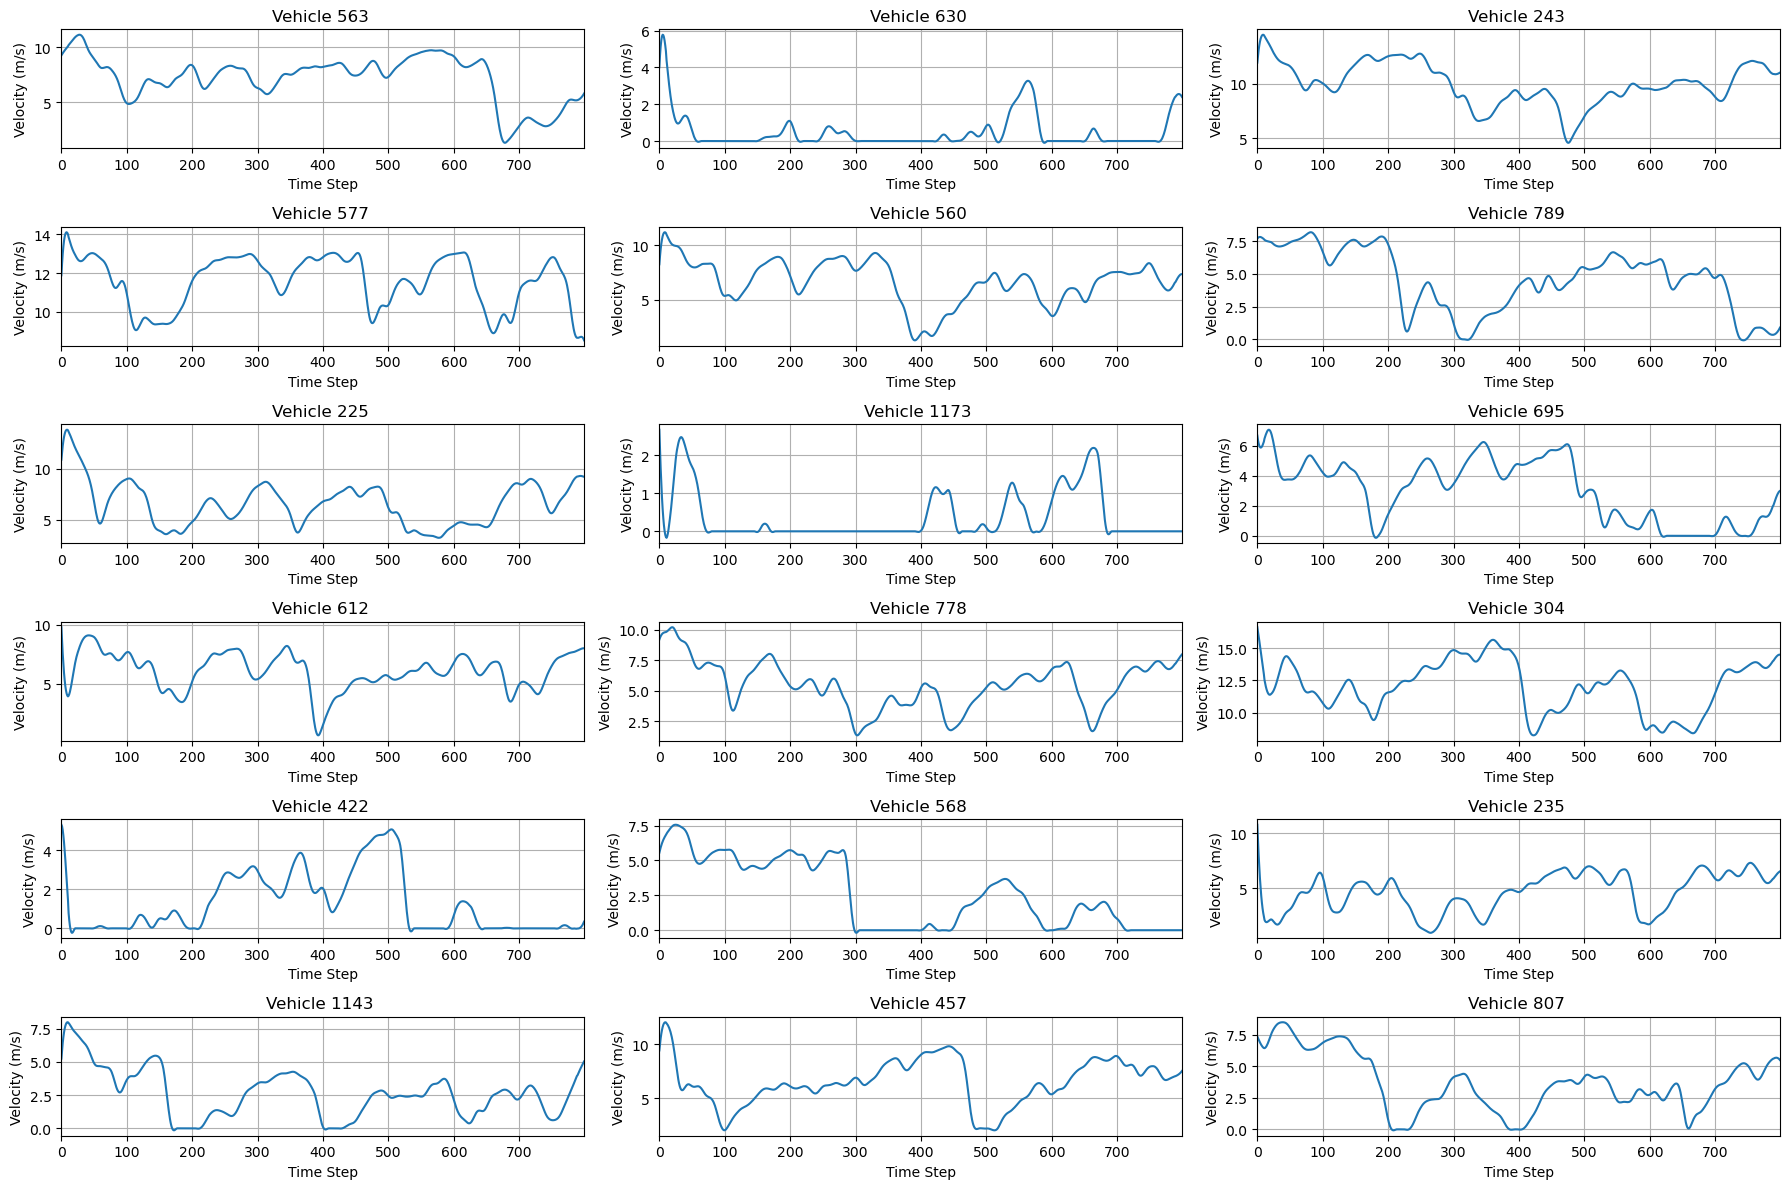

In [111]:
Trajectoryshow_v('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/fake_data_model_epoch_1500.csv')

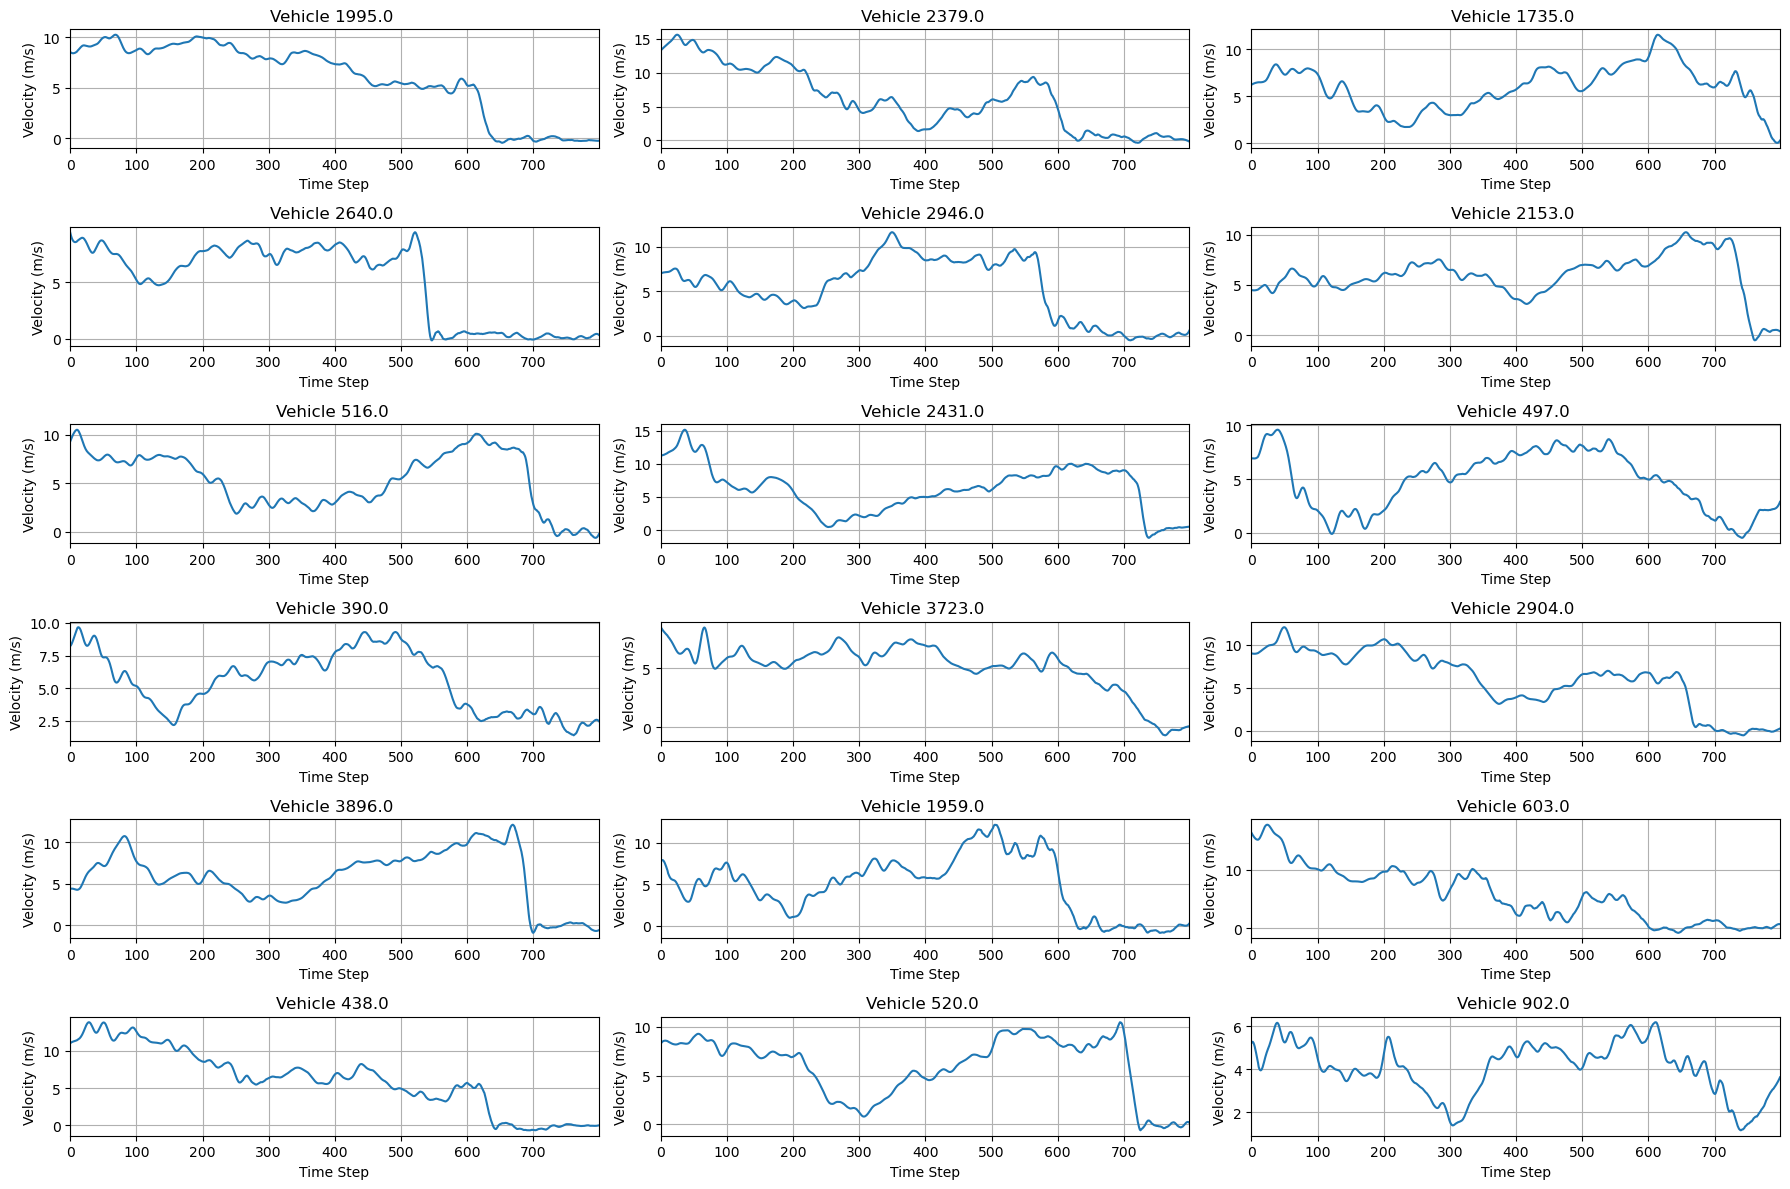

In [114]:
Trajectoryshow_v('C:/Users/19856/Desktop/TimeVAE/timeVAE_smoothed_data_prior_samples.csv' )

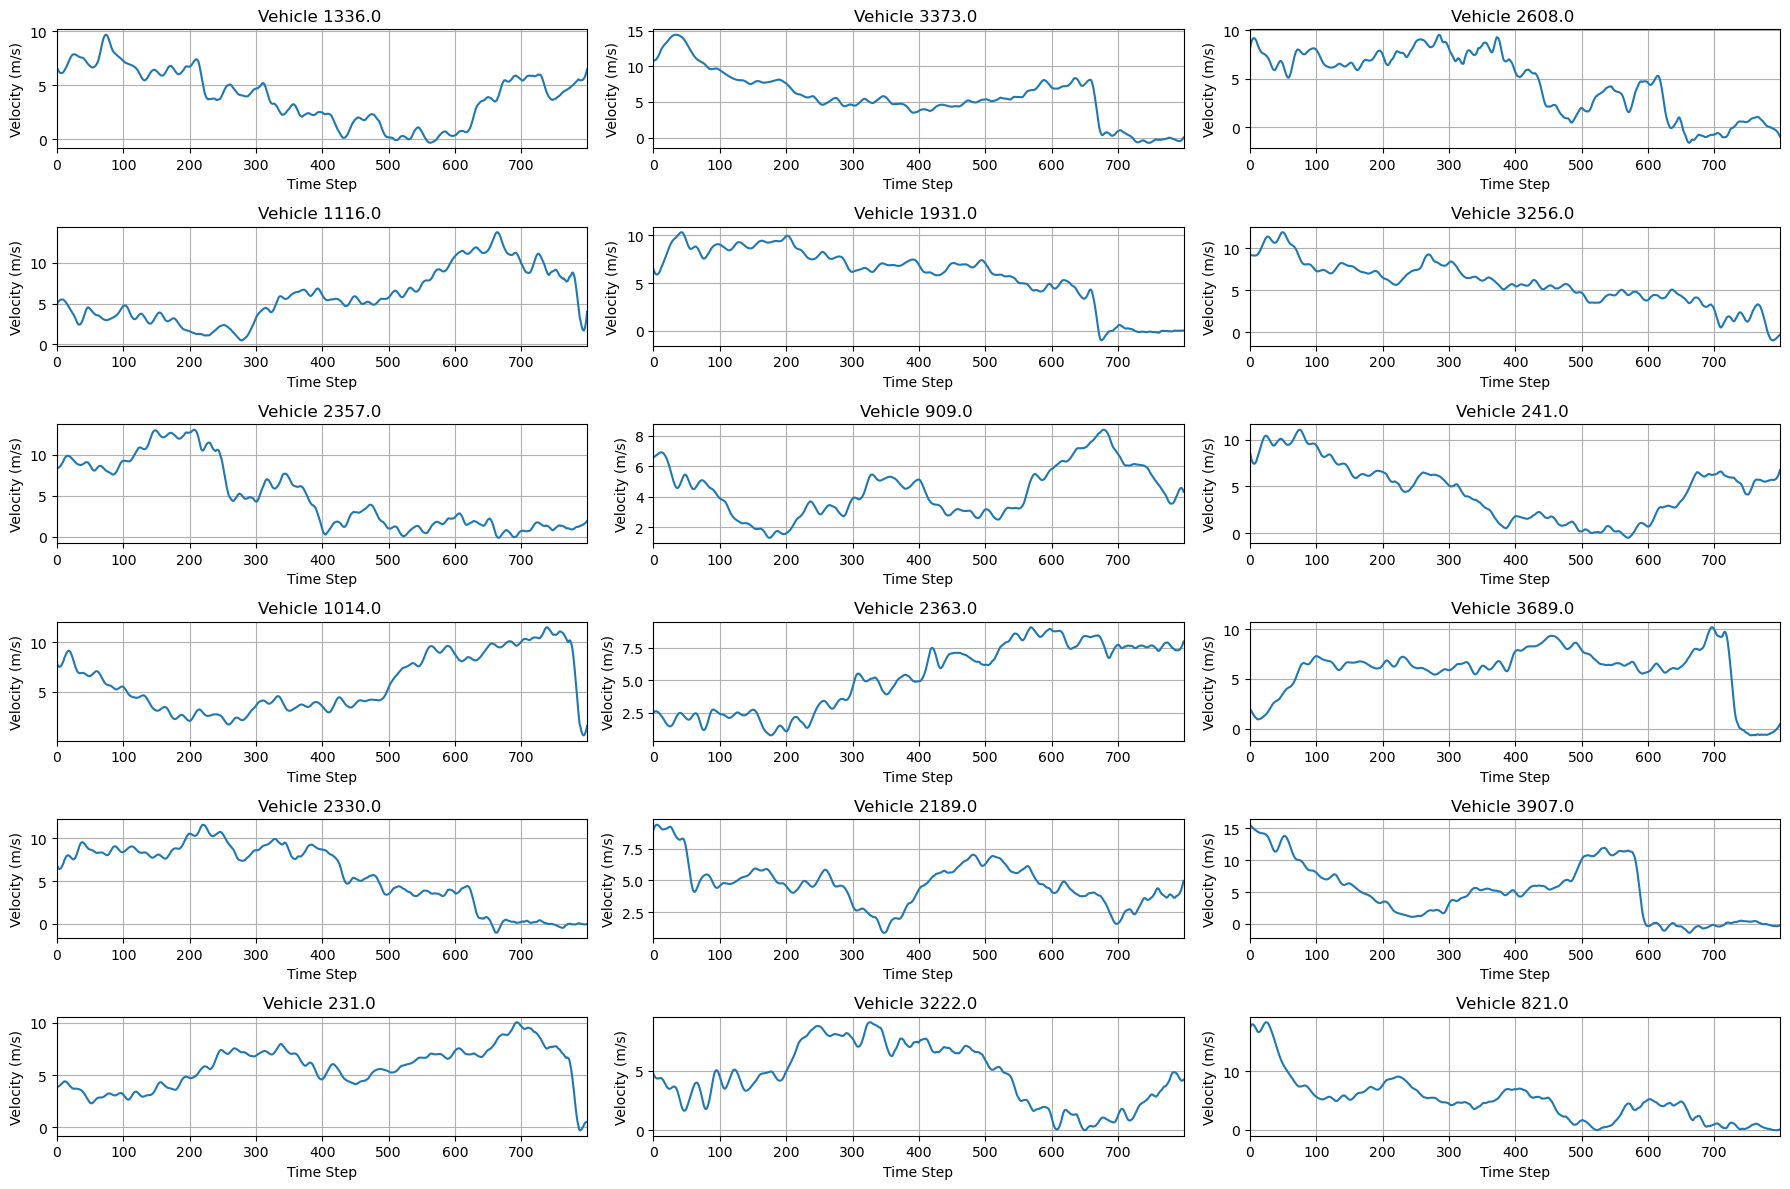

In [117]:
Trajectoryshow_v('C:/Users/19856/Desktop/TimeVAE/vae_conv_smoothed_data_prior_samples.csv' )

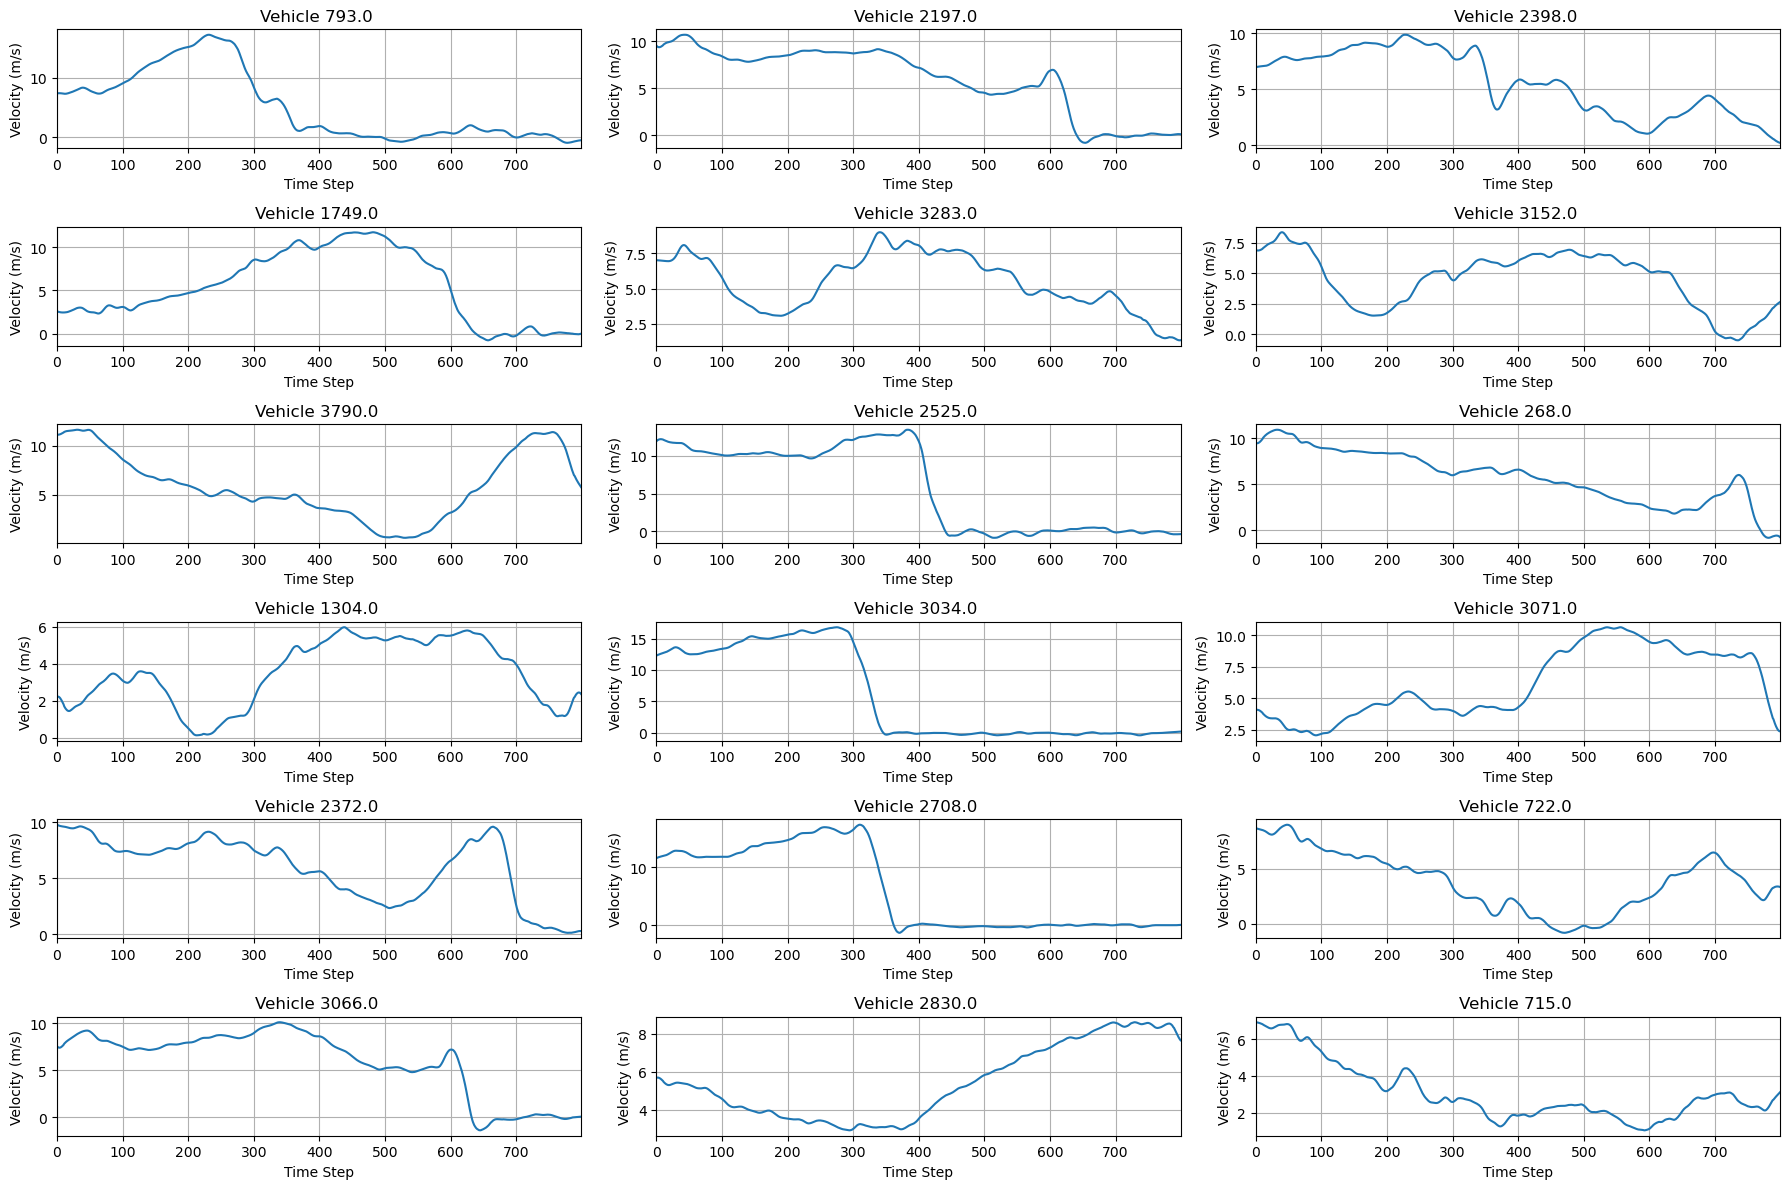

In [72]:
Trajectoryshow_v('C:/Users/19856/Desktop/TimeVAE/vae_dense_smoothed_data_prior_samples.csv' )

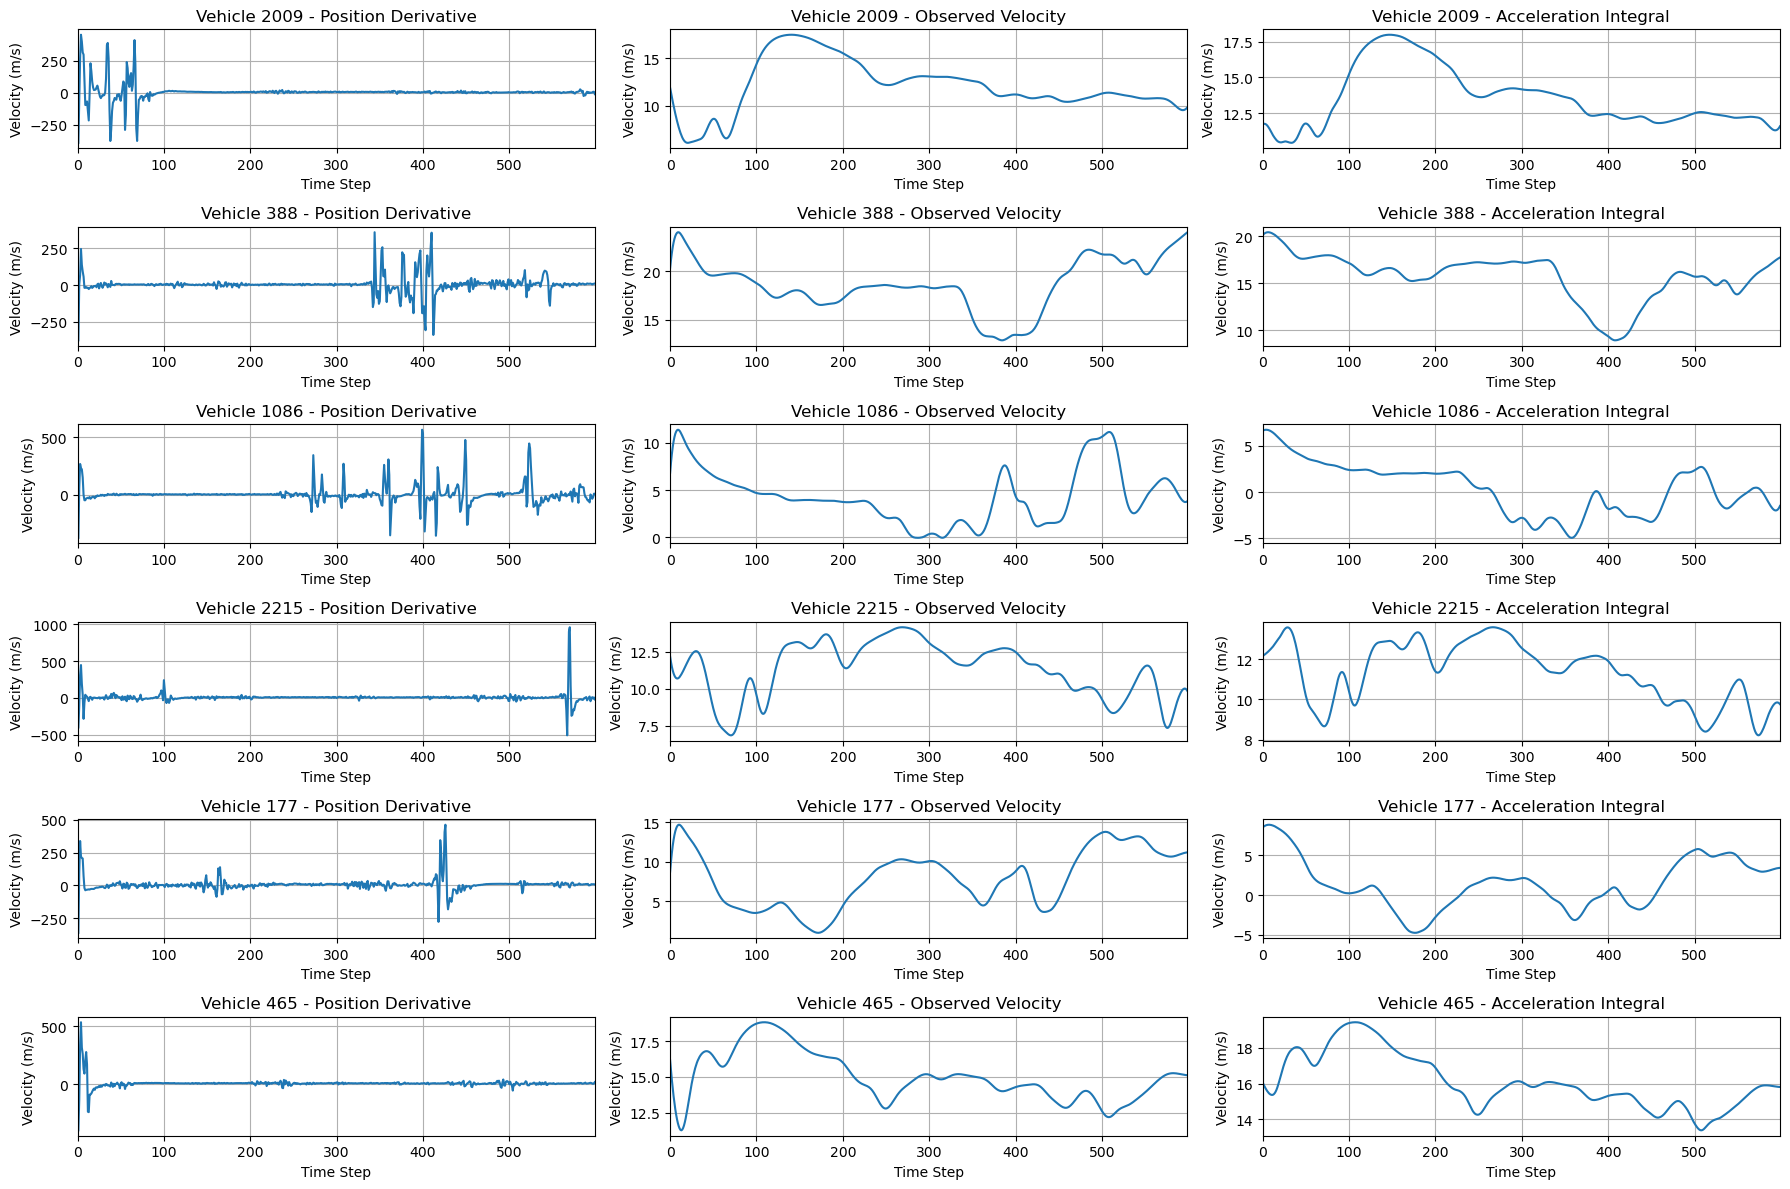

In [3]:
Trajectoryshow('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q600_0.8_2/fake_data_model_epoch_800.csv')

In [ ]:
Trajectoryshow('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q1000_0.9/fake_data_model_epoch_800.csv')

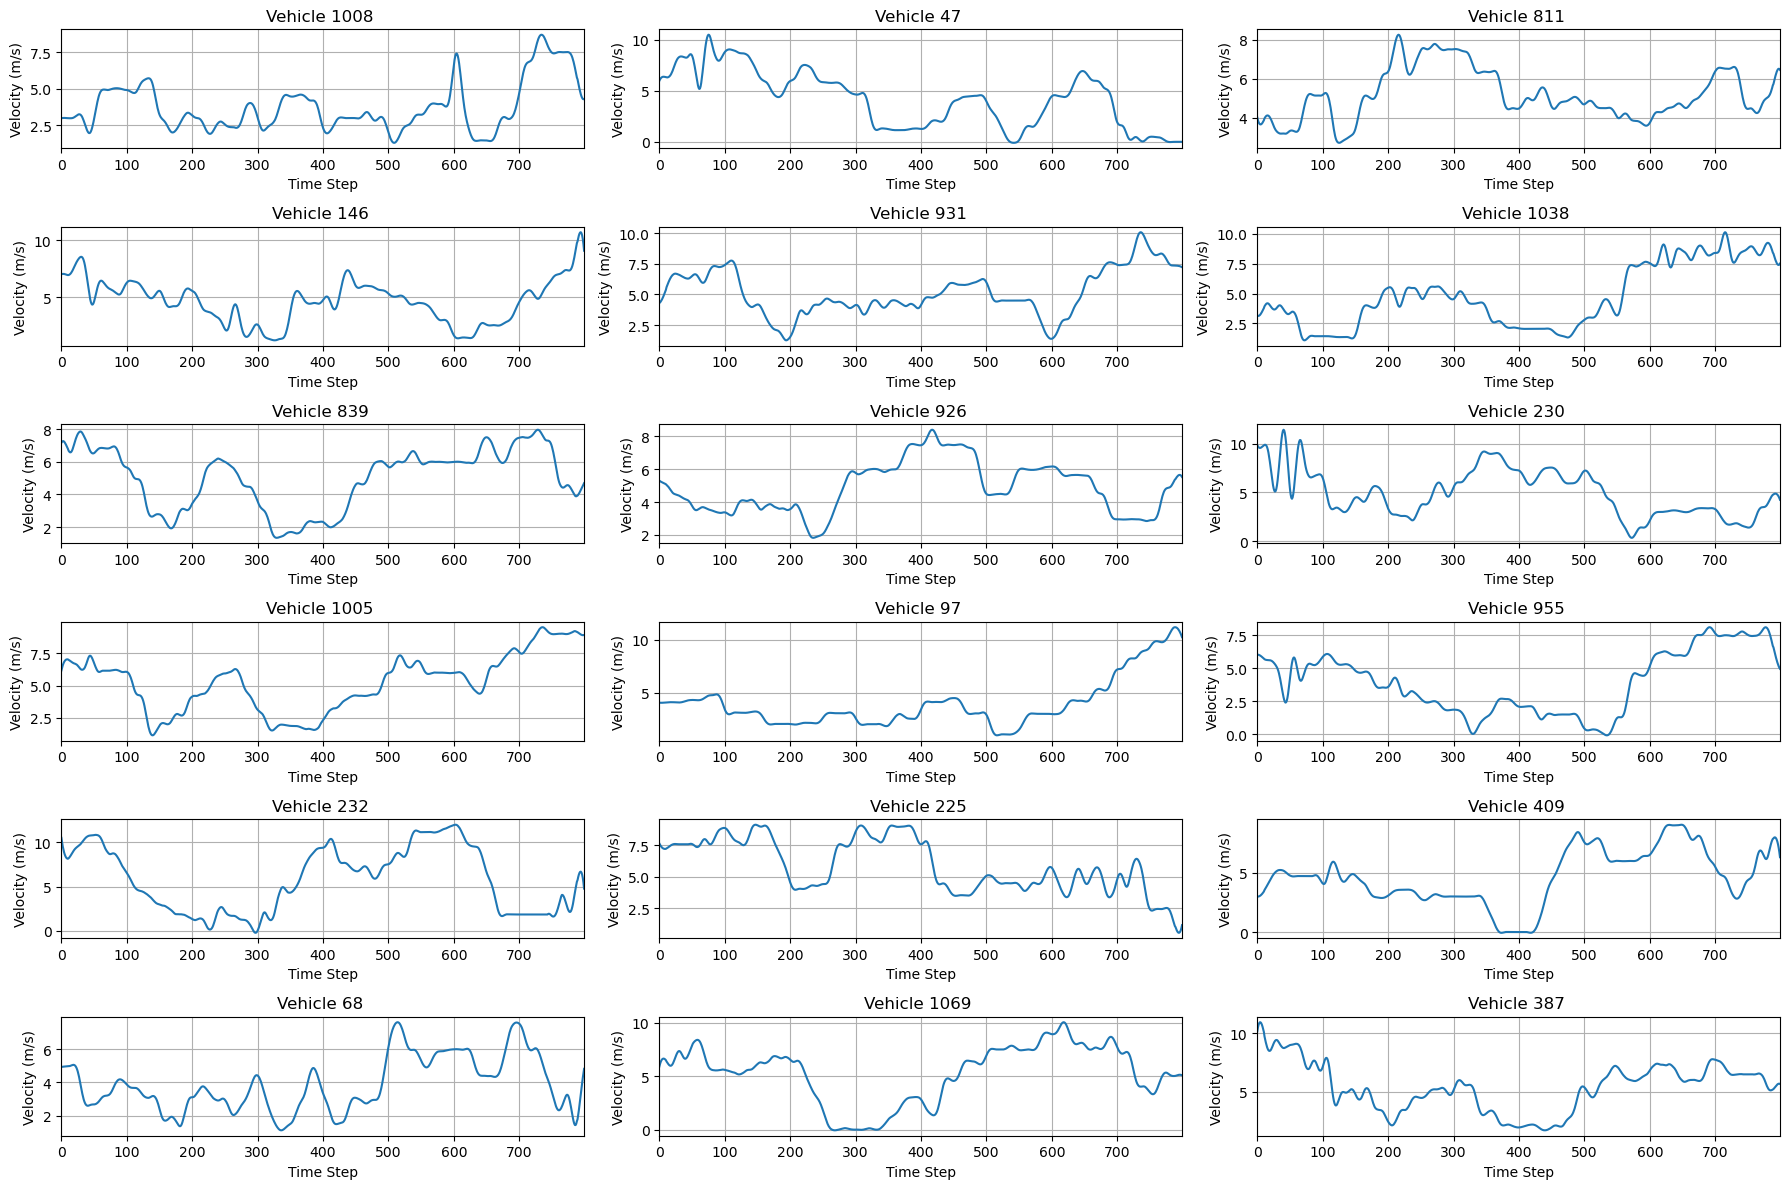

In [120]:
Trajectoryshow_v('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/train_data.csv')

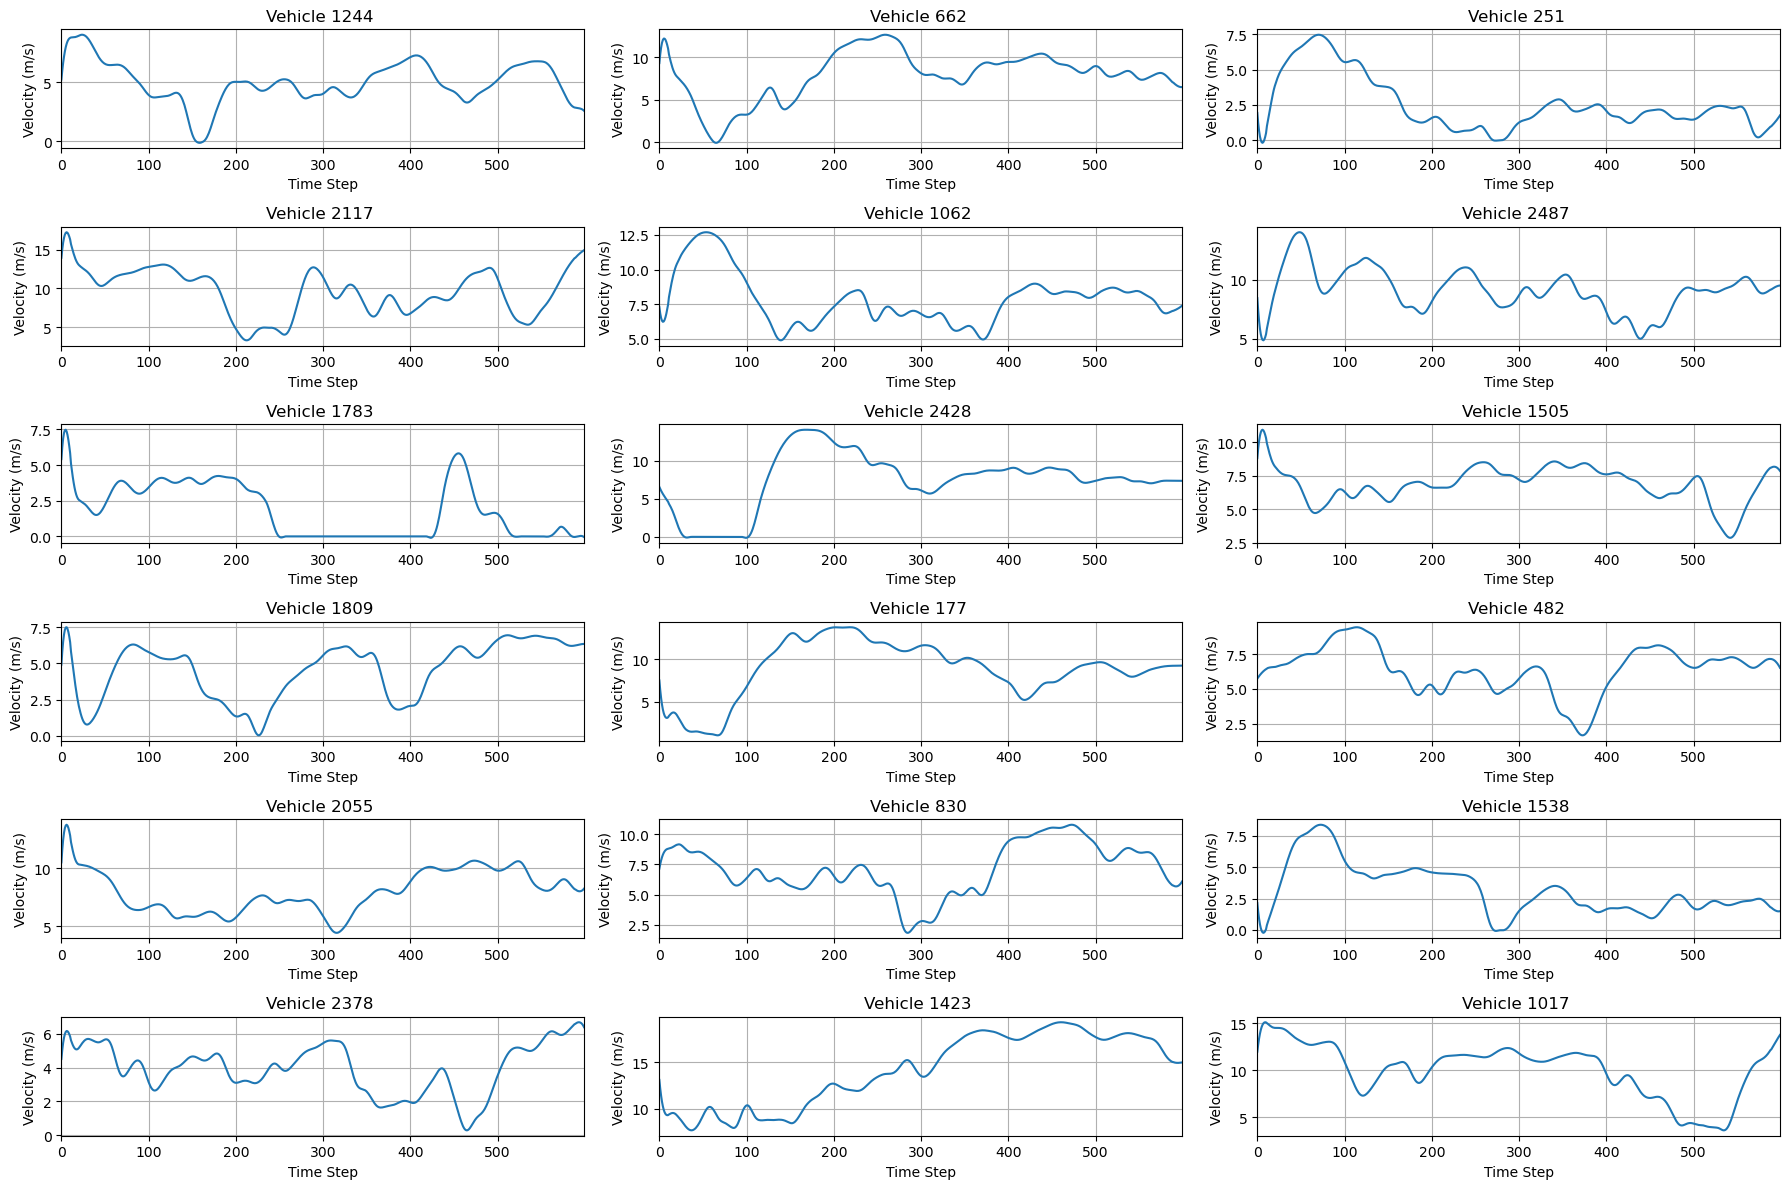

In [96]:
Trajectoryshow_v('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q600_0.8_2/fake_data_model_epoch_1500.csv')

In [ ]:
Trajectoryshow_v('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/fake_data_IDM.csv')

In [ ]:
Trajectoryshow_v('C:/Users/19856/Desktop/timeVAE_smoothed_data_prior_samples.csv' )

In [ ]:
# 读取数据
ShowDistribution(pd.read_csv('C:/Users/19856/Desktop/timeVAE_smoothed_data_prior_samples.csv'))

In [ ]:
ShowDistribution(pd.read_csv('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/fake_data_model_epoch_1500.csv'))

In [ ]:
ShowDistribution(pd.read_csv('D:/pythonProject/pythonProject/timegan-pytorch/output/test_hidden8_e2000_q800_0.8/train_data.csv'))